In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

M1 = np.array(Image.open("monkey.jpg").convert("L"), dtype=float)
print(M1.shape)

size_format = M1.shape[::-1] # resize nhận vào theo thứ tự (rộng, dài)

M2 = np.array(Image.open("duck.jpg").convert("L").resize(size_format), dtype=float)
print(M2.shape)

M3 = np.array(Image.open("cat.jpg").convert("L").resize(size_format), dtype=float)
print(M3.shape)

M4 = np.array(Image.open("wowcat.jpg").convert("L").resize(size_format), dtype=float)
print(M4.shape)

M5 = np.array(Image.open("facemaskdog.jpg").convert("L").resize(size_format), dtype=float)
print(M5.shape)

M6 = np.array(Image.open("blackcat.jpg").convert("L").resize(size_format), dtype=float)
print(M6.shape)

M7 = np.array(Image.open("sadcat.jpg").convert("L").resize(size_format), dtype=float)
print(M7.shape)

M8 = np.array(Image.open("chicken.jpg").convert("L").resize(size_format), dtype=float)
print(M8.shape)

(1575, 1284)
(1575, 1284)
(1575, 1284)
(1575, 1284)
(1575, 1284)
(1575, 1284)
(1575, 1284)
(1575, 1284)


# BÀI 1

In [4]:
# 1/ Biến dữ liệu thành ma trận
H, W = M1.shape

X1 = M1.reshape(1, H * W)
X2 = M2.reshape(1, H * W)
X3 = M3.reshape(1, H * W)
X4 = M4.reshape(1, H * W)
X5 = M5.reshape(1, H * W)
X6 = M6.reshape(1, H * W)
X7 = M7.reshape(1, H * W)
X8 = M8.reshape(1, H * W)

X = np.vstack([X1, X2, X3, X4, X5, X6, X7, X8])

print(X.shape)

(8, 2022300)


X.shape trả về một tuple có phần tử đầu chỉ số hàng hay số lượng bức ảnh, phần tử còn lại chỉ số cột hay tổng số pixels sau khi duỗi ảnh.

In [5]:
# 2/ Phép toán cơ bản
X_mean = np.mean(X, axis=0)

print("Kích thước của X trước khi broadcasting là: \n", X, "\n")

X_center = X - X_mean
print("Kích thước của X sau khi broadcasting là: \n", X_center)

Kích thước của X trước khi broadcasting là: 
 [[171. 171. 171. ... 154. 151. 155.]
 [144. 144. 144. ... 211. 213. 213.]
 [192. 192. 192. ... 222. 222. 222.]
 ...
 [ 39. 114. 143. ... 248. 251. 250.]
 [152. 152. 152. ... 198. 198. 198.]
 [ 16.  16.  16. ...  80.  75.  73.]] 

Kích thước của X sau khi broadcasting là: 
 [[  52.125   42.75    39.125 ...  -27.875  -22.      -8.75 ]
 [  25.125   15.75    12.125 ...   29.125   40.      49.25 ]
 [  73.125   63.75    60.125 ...   40.125   49.      58.25 ]
 ...
 [ -79.875  -14.25    11.125 ...   66.125   78.      86.25 ]
 [  33.125   23.75    20.125 ...   16.125   25.      34.25 ]
 [-102.875 -112.25  -115.875 ... -101.875  -98.     -90.75 ]]


In [6]:
# 3/ Cosine similarity
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis = 1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    return Xn @ Yn.T

In [7]:
# 4/ Truy vấn
query_image = np.array(Image.open("dog.jpg").convert("L").resize(size_format), dtype=float)
query_vector = query_image.reshape(1, -1)

def search(query, top_k=3):
    correlation = cosine_similarity(X, query).flatten()

    sorted_idx = np.argsort(correlation)[::-1]

    top_k_idx = sorted_idx[:top_k]
    top_k_scores = correlation[top_k_idx]

    result = [(int(idx), round(float(score), 4)) for idx, score in zip(top_k_idx, top_k_scores)]

    return result

print(search(query_vector))

[(2, 0.9149), (6, 0.847), (0, 0.8351)]


5/ Nhận xét

Ảnh giống ảnh query dog.jpg nhất là ảnh duck.jpg vì có giá trị tương đồng cosine gần 1 nhất, còn khác ảnh query nhất là ảnh wowcat.jpg do có giá trị cosine xa 1 nhất. Em nhìn bằng mắt thường thấy cũng đúng đúng=)))


# BÀI 2

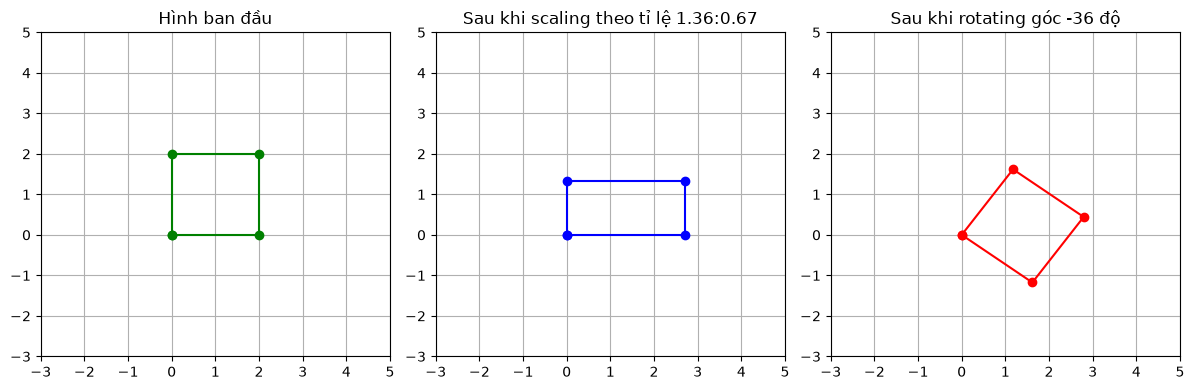

In [8]:
square = np.array([[0, 2, 2, 0, 0], 
                  [0, 0, 2, 2, 0]])
# 1/ Biến đổi tuyến tính
sx, sy = 1.36, 0.67
S = np.array([[sx, 0], 
              [0, sy]])

degrees = -36
theta = np.radians(degrees)
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta), np.cos(theta)]])

scaled_square = S @ square
rotated_square = R @ square

plt.figure(figsize=(12, 4)) # dai, rong

plt.subplot(1, 3, 1) 
plt.plot(square[0, :], square[1, :], '-o', color='green')
plt.title('Hình ban đầu')
plt.grid(True)
plt.xlim(-3, 5)
plt.ylim(-3, 5)

plt.subplot(1, 3, 2)
plt.plot(scaled_square[0, :], scaled_square[1, :], '-o', color='blue')
plt.title(f'Sau khi scaling theo tỉ lệ {sx}:{sy}')
plt.grid(True)
plt.xlim(-3, 5)
plt.ylim(-3, 5)

plt.subplot(1, 3, 3)
plt.plot(rotated_square[0, :], rotated_square[1, :], '-o', color='red')
plt.title(f'Sau khi rotating góc {degrees} độ')
plt.grid(True)
plt.xlim(-3, 5)
plt.ylim(-3, 5)

plt.tight_layout()
plt.show()


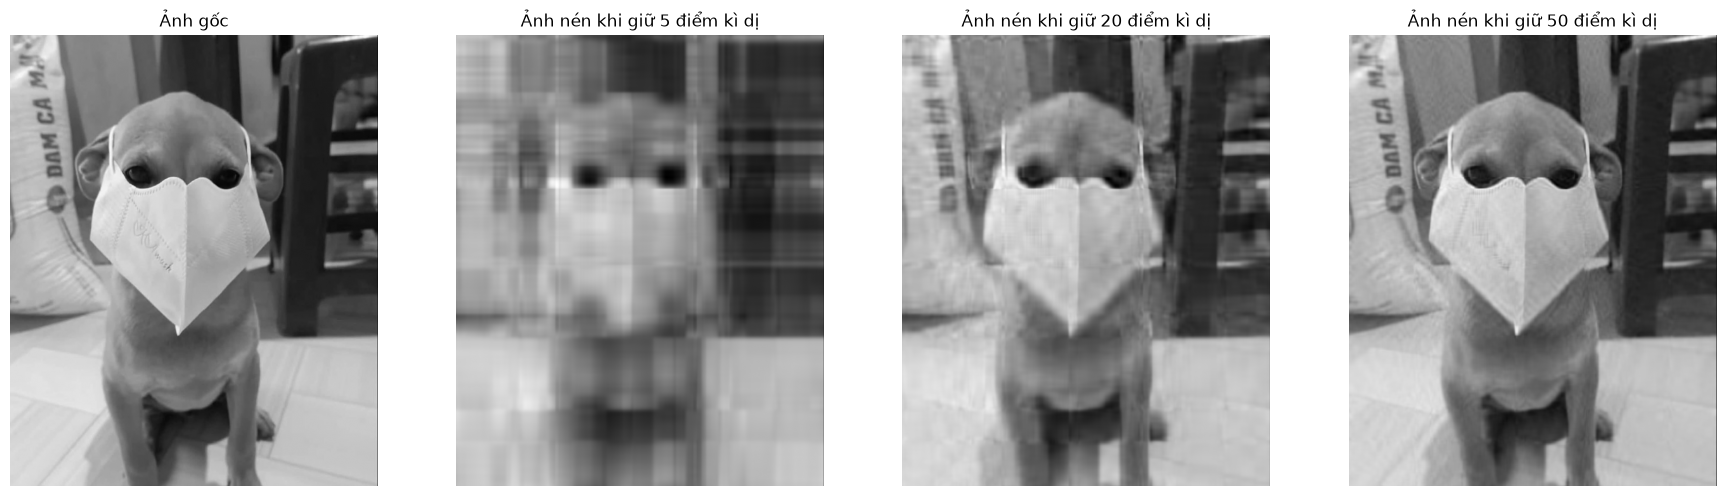

In [9]:
# 2/ Nén ảnh bằng SVD
U, S, Vt = np.linalg.svd(M5, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_list = [5, 20, 50]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(M5, cmap='gray') # imshow() dùng để hiển thị hình ảnh hoặc mảng dữ liệu 2 chiều dưới dạng hình ảnh màu sắc
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

for i, k in enumerate(k_list):
    compressed_img = reconstruct(k)

    next_ax = axes[i + 1]
    next_ax.imshow(compressed_img, cmap='gray')
    next_ax.set_title(f'Ảnh nén khi giữ {k} điểm kì dị')
    next_ax.axis('off')

plt.tight_layout()
plt.show()

Với k = 5, tỉ lệ nén là 0.007071156603866884, sai số tái tạo là 0.13915241338788872.
Với k = 20, tỉ lệ nén là 0.028284626415467536, sai số tái tạo là 0.05688114257114919.
Với k = 50, tỉ lệ nén là 0.07071156603866884, sai số tái tạo là 0.024311815726177414.


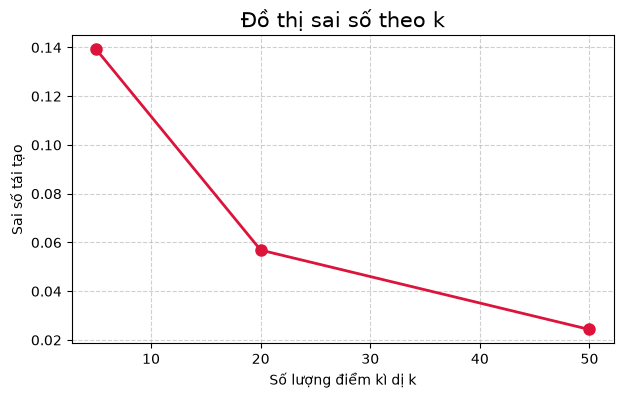

In [10]:
# 3/ Đánh giá
TOTAL_PIXELS = H * W
errors = []
ratios = []

for k in k_list:
    rec_M5 = reconstruct(k)

    k_pixels = k * (H + W + 1)
    ratio = k_pixels / TOTAL_PIXELS
    ratios.append(ratio)

    error = np.linalg.norm(M5 - rec_M5) / np.linalg.norm(M5)
    errors.append(error)

    print(f"Với k = {k}, tỉ lệ nén là {ratio}, sai số tái tạo là {error}.")

plt.figure(figsize=(7,4))

plt.plot(k_list, errors, '-o', color='crimson', linewidth=2, markersize=8)
plt.title('Đồ thị sai số theo k', fontsize=15)
plt.xlabel('Số lượng điểm kì dị k', fontsize=10)
plt.ylabel('Sai số tái tạo', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6) # alpha dùng để điều chỉnh độ trong suốt của line
plt.show()


4/ Nhận xét

Khi số lượng điển kì dị k càng lớn thì sai số tái tạo càng tiến gần về 0, khi đó thì ảnh sẽ rõ nét hơn. Nếu mà xét trong k_list thì k = 50 thì ảnh mới hình dung được.

Sau khi nén SVD thì em thấy ảnh thường có nhiều pixels dư thừa nên 
chỉ cần lưu một số lượng pixels nhất định thì vẫn giữ được đặc trưng của ảnh, 
giúp tăng tốc độ tính toán và xử lí khi train AI...

In [11]:
# BONUS

cum_energy = np.cumsum(S) / np.sum(S) 
# Tính tổng tích luỹ sau đó lấy từng tổng tích luỹ chia cho tổng để ra tỉ lệ

k_over_90 = np.argmax(cum_energy >= 0.90) + 1 # Hàm argmax() trả về index đầu tiên thoả mãn cum_energy >= 90%
print(f"Với k = {k_over_90} thì giữ hơn 90% thông tin")

Với k = 61 thì giữ hơn 90% thông tin
